In [1]:
# CELL 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create project folder in Drive
import os
PROJECT_DIR = '/content/drive/MyDrive/GenAI_Assignment'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints/task1', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints/task2', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints/task3', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints/task4', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/onnx_models', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/manifests', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/optuna_results', exist_ok=True)

print("✅ Google Drive mounted and project folders created!")
print(f"Project directory: {PROJECT_DIR}")

Mounted at /content/drive
✅ Google Drive mounted and project folders created!
Project directory: /content/drive/MyDrive/GenAI_Assignment


In [ ]:
# CELL 2: Install all dependencies
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q optuna mlflow onnx onnxruntime-gpu
!pip install -q scikit-learn scikit-image tqdm matplotlib seaborn
!pip install -q pytorch-ssim

print("✅ All packages installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# CELL 3: Check GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
else:
    print("⚠️ No GPU! Go to Runtime → Change runtime type → T4 GPU")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

In [ ]:
# CELL 4: Download Oxford Pet Dataset
import os, urllib.request, tarfile

DATA_DIR = f'{PROJECT_DIR}/data/oxford-pet'
os.makedirs(DATA_DIR, exist_ok=True)

# Download images
images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
images_tar = f"{DATA_DIR}/images.tar.gz"

if not os.path.exists(f"{DATA_DIR}/images"):
    print("Downloading Oxford Pet images (~800MB)...")
    urllib.request.urlretrieve(images_url, images_tar)
    print("Extracting...")
    with tarfile.open(images_tar, 'r:gz') as tar:
        tar.extractall(DATA_DIR)
    os.remove(images_tar)
    print("✅ Images downloaded and extracted!")
else:
    print("✅ Images already exist!")

# Count images
n_images = len([f for f in os.listdir(f"{DATA_DIR}/images") if f.endswith('.jpg')])
print(f"Total images: {n_images}")

✅ Images already exist!
Total images: 7390


In [ ]:
# CELL 5 (FIXED): Create Face-to-Sketch Dataset
import os
import itertools
import numpy as np
from PIL import Image, ImageFilter, ImageOps

# Ensure PROJECT_DIR is defined
PROJECT_DIR = '/content/drive/MyDrive/GenAI_Assignment'
FS2K_DIR = f'{PROJECT_DIR}/data/FS2K'

# Setup folder directories
for split in ['train', 'test']:
    for sub in ['photo', 'sketch/style1', 'sketch/style2', 'sketch/style3']:
        os.makedirs(f'{FS2K_DIR}/{split}/{sub}', exist_ok=True)

print("Downloading CelebA faces and synthesizing sketch pairs...")

!pip install -q datasets
from datasets import load_dataset

# Stream faces from HuggingFace
ds = load_dataset("nielsr/CelebA-faces", split="train", streaming=True)

count = 0
for item in itertools.islice(ds, 2200):
    img = item['image'].convert('RGB').resize((128, 128))
    split = 'train' if count < 2000 else 'test'
    fname = f'face_{count:05d}.jpg'

    # Save original photo
    img.save(f'{FS2K_DIR}/{split}/photo/{fname}')

    gray = img.convert('L')

    # Style 1: Clean Line Art (Edge detection)
    s1 = ImageOps.invert(gray.filter(ImageFilter.FIND_EDGES)).convert('RGB')
    s1.save(f'{FS2K_DIR}/{split}/sketch/style1/{fname}')

    # Style 2: Soft Shaded (Gaussian blur + edges)
    s2 = ImageOps.invert(gray.filter(ImageFilter.GaussianBlur(1)).filter(ImageFilter.FIND_EDGES)).convert('RGB')
    s2.save(f'{FS2K_DIR}/{split}/sketch/style2/{fname}')

    # Style 3: Pencil / Charcoal Sketch
    inv = ImageOps.invert(gray)
    blur_inv = inv.filter(ImageFilter.GaussianBlur(3))

    gray_np = np.array(gray).astype(float)
    blur_inv_np = np.array(blur_inv).astype(float)

    # Dodge blend algorithm for realistic pencil sketch
    s3_np = np.clip((gray_np * 255.0) / (255.0 - blur_inv_np + 1.0), 0, 255).astype(np.uint8)
    Image.fromarray(s3_np).convert('RGB').save(f'{FS2K_DIR}/{split}/sketch/style3/{fname}')

    count += 1
    if count % 500 == 0:
        print(f"  Processed {count}/2200 samples...")

print(f"\n✅ Created all {count} face-to-sketch pairs in 3 distinct styles!")

dataset_infos.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

  Processed 500/2200 samples...
  Processed 1000/2200 samples...
  Processed 1500/2200 samples...
  Processed 2000/2200 samples...

✅ Created all 2200 face-to-sketch pairs in 3 distinct styles!


In [ ]:
# CELL 6: Create data splits and corruption manifests
import os, json, random
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image

DATA_DIR = f'{PROJECT_DIR}/data/oxford-pet'
MANIFEST_DIR = f'{PROJECT_DIR}/manifests'
os.makedirs(MANIFEST_DIR, exist_ok=True)

# Get all image paths
images_dir = f'{DATA_DIR}/images'
all_images = sorted([
    os.path.join(images_dir, f)
    for f in os.listdir(images_dir)
    if f.lower().endswith('.jpg') and not f.startswith('.')
])

# Get categories for stratified split
categories = []
valid_images = []
for img_path in all_images:
    fname = os.path.basename(img_path)
    parts = fname.rsplit('_', 1)
    if len(parts) == 2:
        categories.append(parts[0])
        valid_images.append(img_path)

# 80/20 split with seed 42
train_paths, val_paths = train_test_split(
    valid_images, test_size=0.2, random_state=42, stratify=categories
)

print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")

# Save split info
with open(f'{MANIFEST_DIR}/data_splits.json', 'w') as f:
    json.dump({'train': train_paths, 'val': val_paths}, f)

# ---- Generate Validation Manifest ----
rng = np.random.RandomState(42)
val_manifest = {}
corruption_types = ['clean', 'salt_pepper', 'gaussian_blur', 'occlusion']

for img_path in val_paths:
    img_key = os.path.basename(img_path)
    ctype = rng.choice(corruption_types)
    entry = {'path': img_path, 'type': ctype}

    if ctype == 'clean':
        entry['label'] = 0
    elif ctype == 'salt_pepper':
        entry['prob'] = float(rng.uniform(0.02, 0.15))
        entry['seed'] = int(rng.randint(0, 100000))
        entry['label'] = 1
    elif ctype == 'gaussian_blur':
        entry['kernel_size'] = int(rng.choice([3, 5, 7]))
        entry['sigma'] = float(rng.uniform(0.5, 2.5))
        entry['label'] = 2
    elif ctype == 'occlusion':
        entry['num_rects'] = int(rng.randint(1, 4))
        entry['target_coverage'] = float(rng.uniform(0.10, 0.35))
        entry['seed'] = int(rng.randint(0, 100000))
        entry['label'] = 3

    val_manifest[img_key] = entry

with open(f'{MANIFEST_DIR}/val_manifest.json', 'w') as f:
    json.dump(val_manifest, f, indent=2)

# ---- Generate Test Manifest ----
test_manifest = {}
sp_probs = [0.03, 0.08, 0.15]
blur_configs = [(3, 0.7), (5, 1.5), (7, 2.5)]
occ_configs = [(1, 0.10), (2, 0.20), (3, 0.35)]
severities = ['low', 'medium', 'high']

for img_path in val_paths[:200]:  # Use 200 images for test
    img_key = os.path.basename(img_path)
    test_manifest[img_key] = {'path': img_path, 'corruptions': {}}

    test_manifest[img_key]['corruptions']['clean'] = [{'type': 'clean', 'severity': 'none'}]

    for i, prob in enumerate(sp_probs):
        test_manifest[img_key]['corruptions'].setdefault('salt_pepper', []).append({
            'type': 'salt_pepper', 'prob': prob, 'severity': severities[i],
            'seed': int(rng.randint(0, 100000))
        })

    for i, (ks, sigma) in enumerate(blur_configs):
        test_manifest[img_key]['corruptions'].setdefault('gaussian_blur', []).append({
            'type': 'gaussian_blur', 'kernel_size': ks, 'sigma': sigma,
            'severity': severities[i]
        })

    for i, (n_rects, cov) in enumerate(occ_configs):
        test_manifest[img_key]['corruptions'].setdefault('occlusion', []).append({
            'type': 'occlusion', 'num_rects': n_rects, 'target_coverage': cov,
            'severity': severities[i], 'seed': int(rng.randint(0, 100000))
        })

with open(f'{MANIFEST_DIR}/test_manifest.json', 'w') as f:
    json.dump(test_manifest, f, indent=2)

print("✅ Data splits and manifests created!")

Training images: 5912
Validation images: 1478
✅ Data splits and manifests created!


In [ ]:
# CELL 7: Corruption Engine
import numpy as np
import torch
import torchvision.transforms.functional as TF
from PIL import Image, ImageFilter
import random

class CorruptionEngine:
    @staticmethod
    def apply_salt_pepper(image_np, prob):
        noisy = image_np.copy()
        h, w, c = noisy.shape
        rng_vals = np.random.random((h, w))
        noisy[rng_vals < (prob / 2)] = 1.0
        noisy[(rng_vals >= prob / 2) & (rng_vals < prob)] = 0.0
        return noisy

    @staticmethod
    def apply_gaussian_blur_tensor(tensor, kernel_size, sigma):
        return TF.gaussian_blur(tensor, kernel_size=[kernel_size, kernel_size], sigma=[sigma, sigma])

    @staticmethod
    def apply_occlusion(image_np, num_rects, target_coverage, seed=None):
        if seed is not None:
            np.random.seed(seed)
        occluded = image_np.copy()
        h, w, c = occluded.shape
        area_per_rect = (target_coverage * h * w) / num_rects
        rects = []
        for _ in range(num_rects):
            aspect = np.random.uniform(0.5, 2.0)
            rh = min(int(np.sqrt(area_per_rect / aspect)), h)
            rw = min(int(rh * aspect), w)
            y = np.random.randint(0, max(1, h - rh))
            x = np.random.randint(0, max(1, w - rw))
            occluded[y:y+rh, x:x+rw, :] = 0.0
            rects.append({'x': x, 'y': y, 'w': rw, 'h': rh})
        return occluded, rects

    @staticmethod
    def random_corruption(image_np):
        ctype = random.choice(['clean', 'salt_pepper', 'gaussian_blur', 'occlusion'])
        if ctype == 'clean':
            return image_np.copy(), 0
        elif ctype == 'salt_pepper':
            prob = random.uniform(0.02, 0.15)
            return CorruptionEngine.apply_salt_pepper(image_np, prob), 1
        elif ctype == 'gaussian_blur':
            ks = random.choice([3, 5, 7])
            sigma = random.uniform(0.5, 2.5)
            t = torch.from_numpy(image_np).permute(2, 0, 1).float()
            blurred = TF.gaussian_blur(t, kernel_size=[ks, ks], sigma=[sigma, sigma])
            return blurred.permute(1, 2, 0).numpy(), 2
        else:
            n = random.randint(1, 3)
            cov = random.uniform(0.10, 0.35)
            occ, _ = CorruptionEngine.apply_occlusion(image_np, n, cov)
            return occ, 3

print("✅ CorruptionEngine defined!")

✅ CorruptionEngine defined!


In [ ]:
# CELL 8: Dataset Classes
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class PetDataset(Dataset):
    def __init__(self, image_paths, mode='train', manifest=None, img_size=128):
        self.image_paths = image_paths
        self.mode = mode
        self.manifest = manifest
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img_key = os.path.basename(img_path)
        clean_img = Image.open(img_path).convert('RGB')
        clean_tensor = self.transform(clean_img)
        clean_np = clean_tensor.permute(1, 2, 0).numpy()

        if self.mode == 'train':
            corrupted_np, label = CorruptionEngine.random_corruption(clean_np)
            corrupted_tensor = torch.from_numpy(corrupted_np).permute(2, 0, 1).float()
        else:
            if self.manifest and img_key in self.manifest:
                entry = self.manifest[img_key]
                corrupted_np, label = self._apply_manifest(clean_np, clean_tensor, entry)
                corrupted_tensor = torch.from_numpy(corrupted_np).permute(2, 0, 1).float()
            else:
                corrupted_tensor = clean_tensor.clone()
                label = 0

        return torch.clamp(corrupted_tensor, 0, 1), clean_tensor, label

    def _apply_manifest(self, clean_np, clean_tensor, entry):
        t = entry['type']
        if t == 'clean':
            return clean_np.copy(), 0
        elif t == 'salt_pepper':
            np.random.seed(entry.get('seed', 42))
            return CorruptionEngine.apply_salt_pepper(clean_np, entry['prob']), 1
        elif t == 'gaussian_blur':
            blurred = TF.gaussian_blur(clean_tensor,
                kernel_size=[entry['kernel_size']]*2, sigma=[entry['sigma']]*2)
            return blurred.permute(1, 2, 0).numpy(), 2
        elif t == 'occlusion':
            np.random.seed(entry.get('seed', 42))
            occ, _ = CorruptionEngine.apply_occlusion(
                clean_np, entry['num_rects'], entry['target_coverage'], entry.get('seed'))
            return occ, 3
        return clean_np.copy(), 0

# Load manifests
with open(f'{MANIFEST_DIR}/val_manifest.json') as f:
    val_manifest = json.load(f)

print("✅ Dataset classes defined!")

✅ Dataset classes defined!


In [ ]:
# CELL 9: Universal Autoencoder Model
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, ch, drop=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Dropout2d(drop),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(True)
    def forward(self, x):
        return self.relu(x + self.block(x))

class UniversalAE(nn.Module):
    def __init__(self, base_ch=64, bottleneck_dim=256, dropout=0.1, n_layers=4, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        channels = [base_ch * (2**i) for i in range(n_layers)]

        # Encoder
        self.enc_blocks = nn.ModuleList()
        in_ch = 3
        for out_ch in channels:
            self.enc_blocks.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
                ResBlock(out_ch, dropout),
                nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
            ))
            in_ch = out_ch

        spatial = 128 // (2**n_layers)
        self.bottleneck_enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1] * spatial * spatial, bottleneck_dim),
            nn.ReLU(True), nn.Dropout(dropout),
        )
        self.bottleneck_dec = nn.Sequential(
            nn.Linear(bottleneck_dim, channels[-1] * spatial * spatial), nn.ReLU(True),
        )
        self.spatial = spatial
        self.last_ch = channels[-1]

        # Decoder
        self.dec_blocks = nn.ModuleList()
        for i in range(len(channels)-1, -1, -1):
            out_ch = channels[i-1] if i > 0 else 3
            in_ch_d = channels[i] * 2 if (use_skip and i < len(channels)-1) else channels[i]
            if i > 0:
                self.dec_blocks.append(nn.Sequential(
                    nn.ConvTranspose2d(in_ch_d, out_ch, 4, stride=2, padding=1),
                    nn.BatchNorm2d(out_ch), nn.ReLU(True),
                    ResBlock(out_ch, dropout),
                ))
            else:
                self.dec_blocks.append(nn.Sequential(
                    nn.ConvTranspose2d(in_ch_d, 3, 4, stride=2, padding=1), nn.Sigmoid(),
                ))

    def forward(self, x):
        skips = []
        h = x
        for block in self.enc_blocks:
            h = block(h)
            skips.append(h)
        z = self.bottleneck_enc(h)
        h = self.bottleneck_dec(z).view(-1, self.last_ch, self.spatial, self.spatial)
        for i, block in enumerate(self.dec_blocks):
            if self.use_skip and i > 0:
                si = len(skips) - 1 - i
                if si >= 0:
                    h = torch.cat([h, skips[si]], dim=1)
            h = block(h)
        return h

class SSIMLoss(nn.Module):
    def __init__(self, window_size=11):
        super().__init__()
        self.ws = window_size
        sigma = 1.5
        coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
        g = torch.exp(-(coords**2) / (2*sigma**2))
        g = g / g.sum()
        w2d = g.unsqueeze(1).mm(g.unsqueeze(0))
        self.register_buffer('window', w2d.unsqueeze(0).unsqueeze(0))

    def forward(self, img1, img2):
        C = img1.shape[1]
        w = self.window.repeat(C, 1, 1, 1).to(img1.device)
        p = self.ws // 2
        mu1 = F.conv2d(img1, w, padding=p, groups=C)
        mu2 = F.conv2d(img2, w, padding=p, groups=C)
        mu1_sq, mu2_sq, mu12 = mu1**2, mu2**2, mu1*mu2
        s1 = F.conv2d(img1*img1, w, padding=p, groups=C) - mu1_sq
        s2 = F.conv2d(img2*img2, w, padding=p, groups=C) - mu2_sq
        s12 = F.conv2d(img1*img2, w, padding=p, groups=C) - mu12
        C1, C2 = 0.01**2, 0.03**2
        ssim = ((2*mu12+C1)*(2*s12+C2)) / ((mu1_sq+mu2_sq+C1)*(s1+s2+C2))
        return ssim.mean()

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.8):
        super().__init__()
        self.alpha = alpha
        self.l1 = nn.L1Loss()
        self.ssim = SSIMLoss()
    def forward(self, pred, target):
        l1 = self.l1(pred, target)
        s = self.ssim(pred, target)
        return self.alpha * l1 + (1-self.alpha) * (1-s), l1, s

print("✅ Universal AE model defined!")

✅ Universal AE model defined!


In [ ]:
# CELL 10 (FIXED): Optuna + Task 1 Final Training
import os
import json
import optuna
import mlflow
import torch
from torch.utils.data import DataLoader
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

# 1. Allow file store & use SQLite database for MLflow
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
db_path = f"{PROJECT_DIR}/mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("Task1_Universal_AE")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"MLflow tracking database: sqlite:///{db_path}")

# 2. Optuna Objective
def task1_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [16, 32])
    bn = trial.suggest_categorical('bottleneck_dim', [128, 256])
    bc = trial.suggest_categorical('base_channels', [32, 48])
    drop = trial.suggest_float('dropout', 0.0, 0.3)
    alpha = trial.suggest_float('alpha', 0.6, 0.95)

    ds_t = PetDataset(train_paths, 'train')
    ds_v = PetDataset(val_paths, 'val', val_manifest)
    dl_t = DataLoader(ds_t, bs, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    dl_v = DataLoader(ds_v, bs, shuffle=False, num_workers=2, pin_memory=True)

    model = UniversalAE(bc, bn, drop, n_layers=4, use_skip=True).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    crit = CombinedLoss(alpha)

    best = float('inf')
    for ep in range(10):
        model.train()
        for c, cl, _ in dl_t:
            c, cl = c.to(device), cl.to(device)
            opt.zero_grad()
            l, _, _ = crit(model(c), cl)
            l.backward()
            opt.step()

        model.eval()
        vl = 0
        with torch.no_grad():
            for c, cl, _ in dl_v:
                l, _, _ = crit(model(c.to(device)), cl.to(device))
                vl += l.item()
        avg_vl = vl / len(dl_v)
        trial.report(avg_vl, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        best = min(best, avg_vl)
    return best

print("🔍 Running Optuna study (15 trials)...")
study1 = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=3)
)
study1.optimize(task1_objective, n_trials=15, timeout=3600)

print(f"\n✅ Optuna Best Trial Value: {study1.best_trial.value:.4f}")
print(f"Optimal Parameters: {study1.best_trial.params}")

# Save Optuna results
os.makedirs(f'{PROJECT_DIR}/optuna_results', exist_ok=True)
with open(f'{PROJECT_DIR}/optuna_results/task1.json', 'w') as f:
    json.dump({
        'best_value': study1.best_trial.value,
        'best_params': study1.best_trial.params,
        'n_trials': len(study1.trials)
    }, f, indent=2)

# 3. Train final model with best parameters
print("\n🏋️ Training final Task 1 model (25 epochs)...")
bp = study1.best_trial.params

with mlflow.start_run(run_name="task1_final"):
    mlflow.log_params(bp)
    ds_t = PetDataset(train_paths, 'train')
    ds_v = PetDataset(val_paths, 'val', val_manifest)
    dl_t = DataLoader(ds_t, bp['batch_size'], shuffle=True, num_workers=2, drop_last=True)
    dl_v = DataLoader(ds_v, bp['batch_size'], shuffle=False, num_workers=2)

    m1 = UniversalAE(bp['base_channels'], bp['bottleneck_dim'], bp['dropout']).to(device)
    opt = torch.optim.AdamW(m1.parameters(), lr=bp['lr'])
    crit = CombinedLoss(bp['alpha'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=25)

    best_vl = float('inf')
    for ep in range(25):
        m1.train()
        tl = 0
        for c, cl, _ in dl_t:
            c, cl = c.to(device), cl.to(device)
            opt.zero_grad()
            l, _, _ = crit(m1(c), cl)
            l.backward()
            opt.step()
            tl += l.item()
        sched.step()

        m1.eval()
        vl = 0
        vp = 0
        n = 0
        with torch.no_grad():
            for c, cl, _ in dl_v:
                c, cl = c.to(device), cl.to(device)
                r = m1(c)
                l, _, _ = crit(r, cl)
                vl += l.item()
                for i in range(r.shape[0]):
                    vp += psnr_metric(
                        cl[i].cpu().numpy().transpose(1,2,0),
                        r[i].cpu().numpy().transpose(1,2,0),
                        data_range=1.0
                    )
                    n += 1

        avg_tl = tl / len(dl_t)
        avg_vl = vl / len(dl_v)
        avg_vp = vp / max(n, 1)

        mlflow.log_metrics({
            'train_loss': avg_tl,
            'val_loss': avg_vl,
            'val_psnr': avg_vp
        }, step=ep)

        if avg_vl < best_vl:
            best_vl = avg_vl
            torch.save({
                'model_state_dict': m1.state_dict(),
                'config': bp
            }, f'{PROJECT_DIR}/checkpoints/task1/best_model.pth')

        if (ep + 1) % 5 == 0:
            print(f"  Epoch {ep+1:02d}/25 | Train Loss: {avg_tl:.4f} | Val Loss: {avg_vl:.4f} | PSNR: {avg_vp:.2f} dB")

print(f"\n✅ Task 1 training complete! Best Val Loss: {best_vl:.4f}")

2026/10/03 14:48:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/03 14:48:49 INFO mlflow.store.db.utils: Updating database tables
2026/10/03 14:48:54 INFO mlflow.tracking.fluent: Experiment with name 'Task1_Universal_AE' does not exist. Creating a new experiment.
[I 2026-10-03 14:48:54,564] A new study created in memory with name: no-name-7b454b71-036c-477e-9cc1-293790e59f83


Using device: cuda
MLflow tracking database: sqlite:////content/drive/MyDrive/GenAI_Assignment/mlflow.db
🔍 Running Optuna study (15 trials)...


[I 2026-10-03 15:22:52,444] Trial 0 finished with value: 0.04770739328988055 and parameters: {'lr': 0.0028351705303274175, 'batch_size': 32, 'bottleneck_dim': 256, 'base_channels': 32, 'dropout': 0.19981552163250701, 'alpha': 0.6603902973727911}. Best is trial 0 with value: 0.04770739328988055.
[I 2026-10-03 15:34:24,059] Trial 1 finished with value: 0.04100028282784401 and parameters: {'lr': 0.0036829279066337216, 'batch_size': 32, 'bottleneck_dim': 128, 'base_channels': 48, 'dropout': 0.05425718413911732, 'alpha': 0.7393654091654385}. Best is trial 1 with value: 0.04100028282784401.
[I 2026-10-03 15:46:18,170] Trial 2 finished with value: 0.033736226839884635 and parameters: {'lr': 0.0004157049340722431, 'batch_size': 16, 'bottleneck_dim': 128, 'base_channels': 48, 'dropout': 0.1631956104621862, 'alpha': 0.833372074774764}. Best is trial 2 with value: 0.033736226839884635.
[I 2026-10-03 15:57:53,897] Trial 3 finished with value: 0.02911316734203633 and parameters: {'lr': 0.0005671349


✅ Optuna Best Trial Value: 0.0291
Optimal Parameters: {'lr': 0.0005671349953753872, 'batch_size': 32, 'bottleneck_dim': 256, 'base_channels': 48, 'dropout': 0.031285560257217536, 'alpha': 0.9225403460649528}

🏋️ Training final Task 1 model (25 epochs)...
  Epoch 05/25 | Train Loss: 0.0436 | Val Loss: 0.0456 | PSNR: 25.86 dB
  Epoch 10/25 | Train Loss: 0.0392 | Val Loss: 0.0308 | PSNR: 29.19 dB
  Epoch 15/25 | Train Loss: 0.0357 | Val Loss: 0.0270 | PSNR: 30.28 dB
  Epoch 20/25 | Train Loss: 0.0318 | Val Loss: 0.0262 | PSNR: 30.55 dB
  Epoch 25/25 | Train Loss: 0.0303 | Val Loss: 0.0249 | PSNR: 30.97 dB

✅ Task 1 training complete! Best Val Loss: 0.0249


In [ ]:
class CorruptionClassifier(nn.Module):
    def __init__(self, bc=32, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,bc,3,padding=1), nn.BatchNorm2d(bc), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc,bc*2,3,padding=1), nn.BatchNorm2d(bc*2), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc*2,bc*4,3,padding=1), nn.BatchNorm2d(bc*4), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc*4,bc*8,3,padding=1), nn.BatchNorm2d(bc*8), nn.ReLU(True), nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(bc*8,256), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(256,128), nn.ReLU(True), nn.Dropout(dropout), nn.Linear(128,4),
        )
    def forward(self, x): return self.head(self.features(x))

class SpecialistAE(nn.Module):
    def __init__(self, bc=48, bn_dim=192, dropout=0.1):
        super().__init__()
        ch = [bc, bc*2, bc*4, bc*8]
        self.enc = nn.ModuleList()
        in_ch = 3
        for out_ch in ch:
            self.enc.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
                nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
            ))
            in_ch = out_ch
        self.bn_e = nn.Sequential(nn.Flatten(), nn.Linear(ch[-1]*8*8, bn_dim), nn.ReLU(True), nn.Dropout(dropout))
        self.bn_d = nn.Sequential(nn.Linear(bn_dim, ch[-1]*8*8), nn.ReLU(True))
        self.last_ch = ch[-1]
        self.dec = nn.ModuleList()
        for i in range(3, -1, -1):
            in_d = ch[i]*2 if i < 3 else ch[i]
            out_d = ch[i-1] if i > 0 else 32
            if i > 0:
                self.dec.append(nn.Sequential(
                    nn.ConvTranspose2d(in_d, out_d, 4, stride=2, padding=1), nn.BatchNorm2d(out_d), nn.ReLU(True)))
            else:
                self.dec.append(nn.Sequential(
                    nn.ConvTranspose2d(in_d, 32, 4, stride=2, padding=1), nn.ReLU(True),
                    nn.Conv2d(32, 3, 3, padding=1), nn.Sigmoid()))
    def forward(self, x):
        skips = []; h = x
        for b in self.enc: h = b(h); skips.append(h)
        h = self.bn_d(self.bn_e(h)).view(-1, self.last_ch, 8, 8)
        for i, b in enumerate(self.dec):
            if i > 0:
                si = len(skips)-1-i
                if si >= 0: h = torch.cat([h, skips[si]], dim=1)
            h = b(h)
        return h

print("✅ Task 2 models defined!")

✅ Task 2 models defined!


🔷 Training classifier (20 epochs)...
  CLS E5/20 | Acc: 0.974
  CLS E10/20 | Acc: 0.981
  CLS E15/20 | Acc: 0.988
  CLS E20/20 | Acc: 0.987

              precision    recall  f1-score   support

       clean       0.97      0.98      0.98       383
        salt       1.00      1.00      1.00       361
        blur       0.99      0.97      0.98       359
         occ       0.99      1.00      1.00       375

    accuracy                           0.99      1478
   macro avg       0.99      0.99      0.99      1478
weighted avg       0.99      0.99      0.99      1478

Confusion Matrix:
 [[377   0   3   3]
 [  0 361   0   0]
 [ 12   0 347   0]
 [  0   0   0 375]]


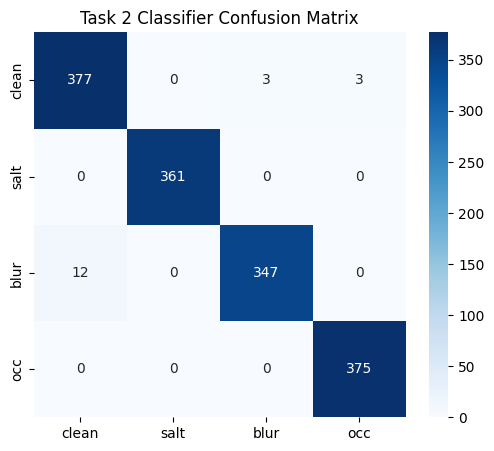


🔷 Training specialist: salt_pepper (20 epochs)...
  salt_pepper E5/20 | Loss: 0.0370
  salt_pepper E10/20 | Loss: 0.0269
  salt_pepper E15/20 | Loss: 0.0216
  salt_pepper E20/20 | Loss: 0.0204
  ✅ salt_pepper best loss: 0.0204

🔷 Training specialist: gaussian_blur (20 epochs)...
  gaussian_blur E5/20 | Loss: 0.0475
  gaussian_blur E10/20 | Loss: 0.0390
  gaussian_blur E15/20 | Loss: 0.0332
  gaussian_blur E20/20 | Loss: 0.0308
  ✅ gaussian_blur best loss: 0.0308

🔷 Training specialist: occlusion (20 epochs)...
  occlusion E5/20 | Loss: 0.0677


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

mlflow.set_experiment("Task2")

# --- Balanced training dataset ---
class BalancedDS(PetDataset):
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx % len(self.image_paths)]).convert('RGB')
        ct = self.transform(img); cn = ct.permute(1,2,0).numpy()
        forced = idx % 4
        if forced == 0: cor, lab = cn.copy(), 0
        elif forced == 1:
            cor = CorruptionEngine.apply_salt_pepper(cn, random.uniform(0.02, 0.15)); lab = 1
        elif forced == 2:
            t = torch.from_numpy(cn).permute(2,0,1).float()
            ks, sig = random.choice([3,5,7]), random.uniform(0.5, 2.5)
            cor = TF.gaussian_blur(t, [ks,ks], [sig,sig]).permute(1,2,0).numpy(); lab = 2
        else:
            cor, _ = CorruptionEngine.apply_occlusion(cn, random.randint(1,3), random.uniform(0.1, 0.35)); lab = 3
        return torch.clamp(torch.from_numpy(cor).permute(2,0,1).float(), 0, 1), ct, lab

class SpecDS(PetDataset):
    def __init__(self, paths, ctype):
        super().__init__(paths, 'train'); self.ctype = ctype
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        ct = self.transform(img); cn = ct.permute(1,2,0).numpy()
        if self.ctype == 'salt_pepper':
            c = CorruptionEngine.apply_salt_pepper(cn, random.uniform(0.02, 0.15))
        elif self.ctype == 'gaussian_blur':
            t = torch.from_numpy(cn).permute(2,0,1).float()
            c = TF.gaussian_blur(t, [random.choice([3,5,7])]*2, [random.uniform(0.5,2.5)]*2).permute(1,2,0).numpy()
        else:
            c, _ = CorruptionEngine.apply_occlusion(cn, random.randint(1,3), random.uniform(0.1, 0.35))
        return torch.clamp(torch.from_numpy(c).permute(2,0,1).float(), 0, 1), ct

with mlflow.start_run(run_name="task2_all"):
    dl_t = DataLoader(BalancedDS(train_paths, 'train'), 32, shuffle=True, num_workers=2, drop_last=True)
    dl_v = DataLoader(PetDataset(val_paths, 'val', val_manifest), 32, shuffle=False, num_workers=2)

    # --- Train Classifier ---
    print("🔷 Training classifier (20 epochs)...")
    cls = CorruptionClassifier(32, 0.3).to(device)
    opt_c = torch.optim.AdamW(cls.parameters(), 1e-3)
    ce = nn.CrossEntropyLoss()

    for ep in range(20):
        cls.train(); tc = tt = 0
        for c, _, lab in dl_t:
            c, lab = c.to(device), lab.to(device)
            opt_c.zero_grad(); l = ce(cls(c), lab); l.backward(); opt_c.step()
            tc += (cls(c).argmax(1)==lab).sum().item(); tt += lab.size(0)
        if (ep+1)%5==0: print(f"  CLS E{ep+1}/20 | Acc: {tc/tt:.3f}")
    torch.save(cls.state_dict(), f'{PROJECT_DIR}/checkpoints/task2/classifier_best.pth')

    # Evaluate classifier
    cls.eval(); ap, al = [], []
    with torch.no_grad():
        for c, _, lab in dl_v:
            ap.extend(cls(c.to(device)).argmax(1).cpu().numpy())
            al.extend(lab.numpy())
    print("\n" + classification_report(al, ap, target_names=['clean','salt','blur','occ']))
    cm = confusion_matrix(al, ap)
    print("Confusion Matrix:\n", cm)
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['clean','salt','blur','occ'],
                yticklabels=['clean','salt','blur','occ'], cmap='Blues')
    plt.title('Task 2 Classifier Confusion Matrix')
    plt.savefig(f'{PROJECT_DIR}/checkpoints/task2/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Train 3 Specialists ---
    crit = CombinedLoss(0.8)
    for st in ['salt_pepper', 'gaussian_blur', 'occlusion']:
        print(f"\n🔷 Training specialist: {st} (20 epochs)...")
        spec = SpecialistAE(48, 192, 0.1).to(device)
        opt_s = torch.optim.AdamW(spec.parameters(), 5e-4)
        dl_s = DataLoader(SpecDS(train_paths, st), 16, shuffle=True, num_workers=2, drop_last=True)

        best_sl = float('inf')
        for ep in range(20):
            spec.train(); tl = 0
            for c, cl in dl_s:
                c, cl = c.to(device), cl.to(device)
                opt_s.zero_grad(); l, _, _ = crit(spec(c), cl)
                l.backward(); opt_s.step(); tl += l.item()
            avg = tl/len(dl_s)
            if avg < best_sl:
                best_sl = avg
                torch.save(spec.state_dict(), f'{PROJECT_DIR}/checkpoints/task2/specialist_{st}_best.pth')
            if (ep+1)%5==0: print(f"  {st} E{ep+1}/20 | Loss: {avg:.4f}")
        print(f"  ✅ {st} best loss: {best_sl:.4f}")

print("\n✅ Task 2 complete!")

In [3]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
# Recreate Task 2 classifier and load its trained weights

cls = CorruptionClassifier(32, 0.3).to(device)

cls.load_state_dict(
    torch.load(
        f'{PROJECT_DIR}/checkpoints/task2/classifier_best.pth',
        map_location=device
    )
)

cls.eval()

print("✅ Classifier loaded successfully!")

✅ Classifier loaded successfully!


=== Warm-up (5 epochs) ===
  Warmup E1/5 | 0.0462
  Warmup E2/5 | 0.0430
  Warmup E3/5 | 0.0417
  Warmup E4/5 | 0.0412
  Warmup E5/5 | 0.0406
=== Joint Fine-tuning (15 epochs) ===
  E3/15 | Train: 0.0494 | Val: 0.0288
    clean→ clean:0.77, salt:0.02, blur:0.18, occ:0.02
    salt→ clean:0.00, salt:0.99, blur:0.01, occ:0.00
    blur→ clean:0.23, salt:0.05, blur:0.68, occ:0.04
    occ→ clean:0.04, salt:0.03, blur:0.03, occ:0.91
  E6/15 | Train: 0.0415 | Val: 0.0279
    clean→ clean:0.86, salt:0.01, blur:0.12, occ:0.02
    salt→ clean:0.00, salt:1.00, blur:0.00, occ:0.00
    blur→ clean:0.13, salt:0.02, blur:0.84, occ:0.02
    occ→ clean:0.03, salt:0.01, blur:0.01, occ:0.95
  E9/15 | Train: 0.0383 | Val: 0.0279
    clean→ clean:0.88, salt:0.01, blur:0.10, occ:0.01
    salt→ clean:0.00, salt:1.00, blur:0.00, occ:0.00
    blur→ clean:0.12, salt:0.01, blur:0.86, occ:0.01
    occ→ clean:0.03, salt:0.01, blur:0.01, occ:0.96
  E12/15 | Train: 0.0368 | Val: 0.0267
    clean→ clean:0.89, salt:0.0

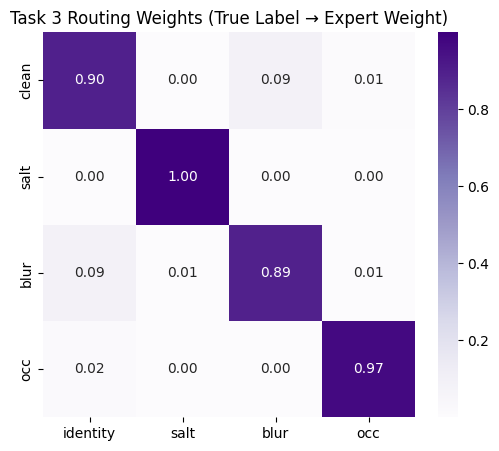


✅ Task 3 complete! Best val loss: 0.0255


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import mlflow
mlflow.set_experiment("Task3_Soft_MoE")


class GatingNet(nn.Module):
    def __init__(self, bc=32, temp=1.5):
        super().__init__(); self.temp = temp
        self.f = nn.Sequential(
            nn.Conv2d(3,bc,3,padding=1), nn.BatchNorm2d(bc), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc,bc*2,3,padding=1), nn.BatchNorm2d(bc*2), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc*2,bc*4,3,padding=1), nn.BatchNorm2d(bc*4), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc*4,bc*8,3,padding=1), nn.BatchNorm2d(bc*8), nn.ReLU(True), nn.AdaptiveAvgPool2d(1),
        )
        self.g = nn.Sequential(nn.Flatten(), nn.Linear(bc*8,128), nn.ReLU(True), nn.Dropout(0.3), nn.Linear(128,4))
    def forward(self, x):
        l = self.g(self.f(x)); return F.softmax(l/self.temp, dim=1), l

with mlflow.start_run(run_name="task3_moe"):
    # Load pretrained components
    cls.load_state_dict(torch.load(f'{PROJECT_DIR}/checkpoints/task2/classifier_best.pth'))
    specs = {}
    for st in ['salt_pepper','gaussian_blur','occlusion']:
        s = SpecialistAE(48,192,0.1).to(device)
        s.load_state_dict(torch.load(f'{PROJECT_DIR}/checkpoints/task2/specialist_{st}_best.pth'))
        specs[st] = s

    gate = GatingNet(32, 1.5).to(device)
    # Transfer classifier weights to gate
    cs, gs = cls.state_dict(), gate.state_dict()
    for k in gs:
        if k in cs and gs[k].shape == cs[k].shape: gs[k] = cs[k]
    gate.load_state_dict(gs)

    dl_t = DataLoader(PetDataset(train_paths, 'train'), 16, shuffle=True, num_workers=2, drop_last=True)
    dl_v = DataLoader(PetDataset(val_paths, 'val', val_manifest), 16, shuffle=False, num_workers=2)
    crit = CombinedLoss(0.8)
    ce_loss = nn.CrossEntropyLoss()

    # Phase 1: Warm-up (freeze experts, train gate only)
    print("=== Warm-up (5 epochs) ===")
    for s in specs.values():
        for p in s.parameters(): p.requires_grad = False
    opt_g = torch.optim.Adam(gate.parameters(), 1e-3)

    for ep in range(5):
        gate.train(); tl = 0
        for c, cl, lab in dl_t:
            c, cl, lab = c.to(device), cl.to(device), lab.to(device)
            opt_g.zero_grad()
            w, logits = gate(c)
            ww = w.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            recon = ww[:,0]*c + ww[:,1]*specs['salt_pepper'](c) + ww[:,2]*specs['gaussian_blur'](c) + ww[:,3]*specs['occlusion'](c)
            l, _, _ = crit(recon, cl)
            l.backward(); opt_g.step(); tl += l.item()
        print(f"  Warmup E{ep+1}/5 | {tl/len(dl_t):.4f}")

    # Phase 2: Joint fine-tune
    print("=== Joint Fine-tuning (15 epochs) ===")
    for s in specs.values():
        for p in s.parameters(): p.requires_grad = True
    opt_all = torch.optim.AdamW(
        list(gate.parameters()) + [p for s in specs.values() for p in s.parameters()], 1e-4)

    best_vl = float('inf')
    for ep in range(15):
        gate.train(); tl = 0
        w_acc = np.zeros((4,4)); l_cnt = np.zeros(4)
        for c, cl, lab in dl_t:
            c, cl, lab = c.to(device), cl.to(device), lab.to(device)
            opt_all.zero_grad()
            w, logits = gate(c)
            ww = w.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            recon = ww[:,0]*c + ww[:,1]*specs['salt_pepper'](c) + ww[:,2]*specs['gaussian_blur'](c) + ww[:,3]*specs['occlusion'](c)
            l, _, _ = crit(recon, cl)
            total = l + 0.1*ce_loss(logits, lab) + 0.01*((w.mean(0)-0.25)**2).sum()
            total.backward(); torch.nn.utils.clip_grad_norm_(list(gate.parameters())+[p for s in specs.values() for p in s.parameters()], 1.0)
            opt_all.step(); tl += total.item()
            with torch.no_grad():
                for i in range(4):
                    m = (lab==i)
                    if m.sum()>0: w_acc[i]+=w[m].mean(0).cpu().numpy(); l_cnt[i]+=1

        gate.eval(); vl = 0
        with torch.no_grad():
            for c, cl, lab in dl_v:
                c, cl, lab = c.to(device), cl.to(device), lab.to(device)
                w, logits = gate(c)
                ww = w.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
                recon = ww[:,0]*c + ww[:,1]*specs['salt_pepper'](c) + ww[:,2]*specs['gaussian_blur'](c) + ww[:,3]*specs['occlusion'](c)
                l, _, _ = crit(recon, cl); vl += l.item()
        avg_vl = vl/len(dl_v)

        if avg_vl < best_vl:
            best_vl = avg_vl
            torch.save({'gate': gate.state_dict(),
                        's1': specs['salt_pepper'].state_dict(),
                        's2': specs['gaussian_blur'].state_dict(),
                        's3': specs['occlusion'].state_dict()},
                       f'{PROJECT_DIR}/checkpoints/task3/soft_moe_best.pth')

        if (ep+1)%3==0:
            print(f"  E{ep+1}/15 | Train: {tl/len(dl_t):.4f} | Val: {avg_vl:.4f}")
            names = ['clean','salt','blur','occ']
            for i in range(4):
                if l_cnt[i]>0:
                    ws = ", ".join([f"{names[j]}:{w_acc[i][j]/l_cnt[i]:.2f}" for j in range(4)])
                    print(f"    {names[i]}→ {ws}")

    # Save routing heatmap
    plt.figure(figsize=(6,5))
    for i in range(4):
        if l_cnt[i]>0: w_acc[i]/=l_cnt[i]
    sns.heatmap(w_acc, annot=True, fmt='.2f', xticklabels=['identity','salt','blur','occ'],
                yticklabels=['clean','salt','blur','occ'], cmap='Purples')
    plt.title('Task 3 Routing Weights (True Label → Expert Weight)')
    plt.savefig(f'{PROJECT_DIR}/checkpoints/task3/routing_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\n✅ Task 3 complete! Best val loss: {best_vl:.4f}")

Using: cuda

Checking dataset directories...
Photo: /content/drive/MyDrive/GenAI_Assignment/data/FS2K/train/photo
Sketch: /content/drive/MyDrive/GenAI_Assignment/data/FS2K/train/sketch/style1
Sketch: /content/drive/MyDrive/GenAI_Assignment/data/FS2K/train/sketch/style2
Sketch: /content/drive/MyDrive/GenAI_Assignment/data/FS2K/train/sketch/style3

Task 4 training samples: 6000

Generator parameters: 5224483
Discriminator parameters: 710465
GAN E5/30 | D: 0.903 | G_L1: 0.092
GAN E10/30 | D: 0.996 | G_L1: 0.078
GAN E15/30 | D: 0.985 | G_L1: 0.073
GAN E20/30 | D: 0.909 | G_L1: 0.071
GAN E25/30 | D: 0.784 | G_L1: 0.068
GAN E30/30 | D: 0.671 | G_L1: 0.069


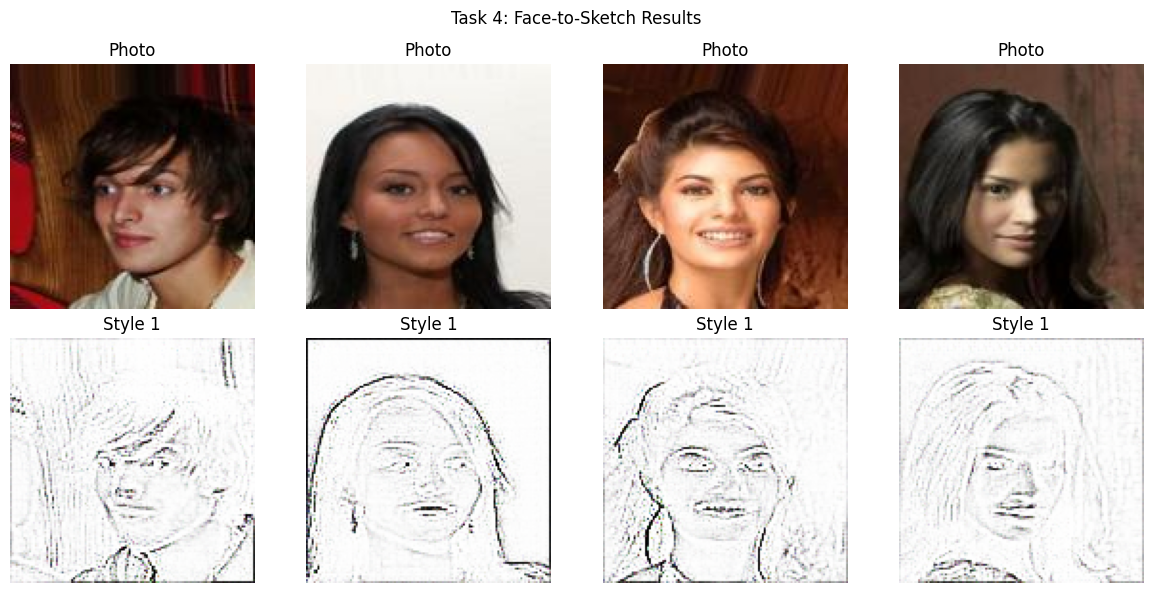


✅ Task 4 complete! Best G_L1: 0.0682
Generator saved to: /content/drive/MyDrive/GenAI_Assignment/checkpoints/task4/gen_best.pth
Sample results saved to: /content/drive/MyDrive/GenAI_Assignment/checkpoints/task4/samples.png


In [5]:
# ============================================================
# TASK 4 — CONDITIONAL GAN (cGAN) FOR PHOTO → SKETCH
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image

import mlflow


# ------------------------------------------------------------
# 1. DEVICE + MLflow
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

mlflow.set_experiment("Task4_CGAN")


# ------------------------------------------------------------
# 2. GENERATOR
# ------------------------------------------------------------

class Gen(nn.Module):
    def __init__(self, bc=32, sd=32):
        super().__init__()

        # Style embedding
        self.se = nn.Embedding(3, sd)
        self.sp = nn.Linear(sd, bc * 8)

        # Encoder
        self.e1 = nn.Sequential(
            nn.Conv2d(3, bc, 4, 2, 1),
            nn.LeakyReLU(0.2, True)
        )

        self.e2 = nn.Sequential(
            nn.Conv2d(bc, bc * 2, 4, 2, 1),
            nn.InstanceNorm2d(bc * 2),
            nn.LeakyReLU(0.2, True)
        )

        self.e3 = nn.Sequential(
            nn.Conv2d(bc * 2, bc * 4, 4, 2, 1),
            nn.InstanceNorm2d(bc * 4),
            nn.LeakyReLU(0.2, True)
        )

        self.e4 = nn.Sequential(
            nn.Conv2d(bc * 4, bc * 8, 4, 2, 1),
            nn.InstanceNorm2d(bc * 8),
            nn.LeakyReLU(0.2, True)
        )

        # Bottleneck
        self.bot = nn.Sequential(
            nn.Conv2d(bc * 8 + bc * 8, bc * 8, 4, 2, 1),
            nn.ReLU(True)
        )

        # Decoder
        self.d1 = nn.Sequential(
            nn.ConvTranspose2d(bc * 8, bc * 8, 4, 2, 1),
            nn.InstanceNorm2d(bc * 8),
            nn.ReLU(True),
            nn.Dropout(0.5)
        )

        self.d2 = nn.Sequential(
            nn.ConvTranspose2d(bc * 16, bc * 4, 4, 2, 1),
            nn.InstanceNorm2d(bc * 4),
            nn.ReLU(True)
        )

        self.d3 = nn.Sequential(
            nn.ConvTranspose2d(bc * 8, bc * 2, 4, 2, 1),
            nn.InstanceNorm2d(bc * 2),
            nn.ReLU(True)
        )

        self.d4 = nn.Sequential(
            nn.ConvTranspose2d(bc * 4, bc, 4, 2, 1),
            nn.ReLU(True)
        )

        self.fin = nn.Sequential(
            nn.ConvTranspose2d(bc * 2, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x, s):

        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)

        # Convert style ID into spatial feature map
        sf = self.sp(
            self.se(s)
        ).unsqueeze(-1).unsqueeze(-1)

        # Expand style feature to match e4 spatial dimensions
        sf = sf.expand(-1, -1, e4.size(2), e4.size(3))

        b = self.bot(
            torch.cat([e4, sf], 1)
        )

        d1_out = self.d1(b)
        d1 = torch.cat([d1_out, e4], 1)

        d2_out = self.d2(d1)
        d2 = torch.cat([d2_out, e3], 1)

        d3_out = self.d3(d2)
        d3 = torch.cat([d3_out, e2], 1)

        d4_out = self.d4(d3)
        d4 = torch.cat([d4_out, e1], 1)

        return self.fin(d4)


# ------------------------------------------------------------
# 3. DISCRIMINATOR
# ------------------------------------------------------------

class Disc(nn.Module):
    def __init__(self, bc=32, sd=32):
        super().__init__()

        # Style embedding
        self.se = nn.Embedding(3, sd)

        # Convert style embedding to 128x128 spatial map
        self.sp = nn.Linear(sd, 128 * 128)

        self.m = nn.Sequential(

            # photo (3) + sketch (3) + style map (1) = 7 channels
            nn.Conv2d(7, bc, 4, 2, 1),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(bc, bc * 2, 4, 2, 1),
            nn.InstanceNorm2d(bc * 2),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(bc * 2, bc * 4, 4, 2, 1),
            nn.InstanceNorm2d(bc * 4),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(bc * 4, 1, 4, 1, 1)
        )

    def forward(self, p, sk, st):

        sm = self.sp(
            self.se(st)
        ).view(-1, 1, 128, 128)

        x = torch.cat([p, sk, sm], 1)

        return self.m(x)


# ------------------------------------------------------------
# 4. DATASET
# ------------------------------------------------------------

class SketchDS(Dataset):

    def __init__(self, photo_dir, sketch_dirs, augment=True):

        self.photos = []
        self.sketches = []
        self.styles = []

        for si, sd in enumerate(sketch_dirs):

            if not os.path.exists(sd):
                print(f"Warning: sketch directory not found: {sd}")
                continue

            for f in sorted(os.listdir(sd)):

                if f.lower().endswith(('.jpg', '.jpeg', '.png')):

                    pp = os.path.join(photo_dir, f)

                    sketch_path = os.path.join(sd, f)

                    if os.path.exists(pp):

                        self.photos.append(pp)
                        self.sketches.append(sketch_path)
                        self.styles.append(si)

        self.tf = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])

        self.aug = augment

    def __len__(self):
        return len(self.photos)

    def __getitem__(self, i):

        p = Image.open(
            self.photos[i]
        ).convert('RGB')

        s = Image.open(
            self.sketches[i]
        ).convert('RGB')

        # Apply same resize + tensor conversion
        p = self.tf(p)
        s = self.tf(s)

        # Convert [0,1] → [-1,1]
        p = p * 2 - 1
        s = s * 2 - 1

        # Same horizontal flip for photo and sketch
        if self.aug and random.random() > 0.5:

            p = TF.hflip(p)
            s = TF.hflip(s)

        return p, s, self.styles[i]


# ------------------------------------------------------------
# 5. CREATE DATASET
# ------------------------------------------------------------

FS2K_DIR = f'{PROJECT_DIR}/data/FS2K'

photo_dir = f'{FS2K_DIR}/train/photo'

sketch_dirs = [
    f'{FS2K_DIR}/train/sketch/style1',
    f'{FS2K_DIR}/train/sketch/style2',
    f'{FS2K_DIR}/train/sketch/style3'
]

print("\nChecking dataset directories...")
print("Photo:", photo_dir)

for sd in sketch_dirs:
    print("Sketch:", sd)


ds4 = SketchDS(
    photo_dir,
    sketch_dirs,
    augment=True
)

print(f"\nTask 4 training samples: {len(ds4)}")

if len(ds4) == 0:
    raise RuntimeError(
        "No Task 4 training samples found. "
        "Please check the FS2K dataset paths."
    )


# ------------------------------------------------------------
# 6. DATALOADER
# ------------------------------------------------------------

# num_workers=0 is intentional:
# it prevents hidden worker-process errors while debugging.

dl4 = DataLoader(
    ds4,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    drop_last=True
)


# ------------------------------------------------------------
# 7. CREATE MODELS
# ------------------------------------------------------------

gen = Gen(32, 32).to(device)

disc = Disc(32, 32).to(device)

print("\nGenerator parameters:",
      sum(p.numel() for p in gen.parameters()))

print("Discriminator parameters:",
      sum(p.numel() for p in disc.parameters()))


# ------------------------------------------------------------
# 8. OPTIMIZERS + LOSSES
# ------------------------------------------------------------

g_opt = torch.optim.Adam(
    gen.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

d_opt = torch.optim.Adam(
    disc.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

bce = nn.BCEWithLogitsLoss()

l1 = nn.L1Loss()


# ------------------------------------------------------------
# 9. TRAINING
# ------------------------------------------------------------

os.makedirs(
    f'{PROJECT_DIR}/checkpoints/task4',
    exist_ok=True
)

best_gl = float('inf')


with mlflow.start_run(run_name="task4_cgan"):

    mlflow.log_param("epochs", 30)
    mlflow.log_param("batch_size", 16)
    mlflow.log_param("image_size", 128)
    mlflow.log_param("learning_rate", 2e-4)
    mlflow.log_param("lambda_l1", 100)

    for ep in range(30):

        gen.train()
        disc.train()

        gl_total = 0.0
        dl_total = 0.0

        for ph, sk, st in dl4:

            ph = ph.to(device)
            sk = sk.to(device)
            st = st.to(device)

            # =================================================
            # DISCRIMINATOR STEP
            # =================================================

            d_opt.zero_grad()

            # Generate fake sketch
            fk = gen(ph, st)

            # Real pair
            real_logits = disc(ph, sk, st)

            # Fake pair
            fake_logits = disc(ph, fk.detach(), st)

            real_target = torch.ones_like(real_logits)
            fake_target = torch.zeros_like(fake_logits)

            dr = bce(
                real_logits,
                real_target
            )

            df = bce(
                fake_logits,
                fake_target
            )

            d_loss = dr + df

            d_loss.backward()

            d_opt.step()

            dl_total += d_loss.item()


            # =================================================
            # GENERATOR STEP
            # =================================================

            g_opt.zero_grad()

            fk = gen(ph, st)

            fake_logits = disc(ph, fk, st)

            # Generator wants discriminator to classify fake
            # sketches as real
            ga = bce(
                fake_logits,
                torch.ones_like(fake_logits)
            )

            # Reconstruction loss
            gl1 = l1(fk, sk)

            # Total generator loss
            g_loss = ga + 100 * gl1

            g_loss.backward()

            g_opt.step()

            gl_total += gl1.item()


        # -----------------------------------------------------
        # Epoch averages
        # -----------------------------------------------------

        avg_d = dl_total / len(dl4)
        avg_gl = gl_total / len(dl4)

        mlflow.log_metric(
            "d_loss",
            avg_d,
            step=ep
        )

        mlflow.log_metric(
            "g_l1",
            avg_gl,
            step=ep
        )

        if avg_gl < best_gl:

            best_gl = avg_gl

            torch.save(
                gen.state_dict(),
                f'{PROJECT_DIR}/checkpoints/task4/gen_best.pth'
            )

        if (ep + 1) % 5 == 0:

            print(
                f"GAN E{ep+1}/30 | "
                f"D: {avg_d:.3f} | "
                f"G_L1: {avg_gl:.3f}"
            )


# ------------------------------------------------------------
# 10. SAMPLE OUTPUTS
# ------------------------------------------------------------

gen.eval()

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)

with torch.no_grad():

    for i in range(4):

        ph, sk, st = ds4[i]

        ph_d = ph.unsqueeze(0).to(device)

        st_d = torch.tensor(
            [st],
            dtype=torch.long,
            device=device
        )

        fk = gen(
            ph_d,
            st_d
        )[0].cpu()

        # Photo
        axes[0, i].imshow(
            ((ph + 1) / 2)
            .permute(1, 2, 0)
            .clip(0, 1)
        )

        axes[0, i].set_title("Photo")

        # Generated sketch
        axes[1, i].imshow(
            ((fk + 1) / 2)
            .permute(1, 2, 0)
            .clip(0, 1)
        )

        axes[1, i].set_title(
            f"Style {st + 1}"
        )

        axes[0, i].axis('off')
        axes[1, i].axis('off')


plt.suptitle(
    'Task 4: Face-to-Sketch Results'
)

plt.tight_layout()

sample_path = (
    f'{PROJECT_DIR}/checkpoints/task4/samples.png'
)

plt.savefig(
    sample_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ------------------------------------------------------------
# 11. FINAL MESSAGE
# ------------------------------------------------------------

print(
    f"\n✅ Task 4 complete! "
    f"Best G_L1: {best_gl:.4f}"
)

print(
    f"Generator saved to: "
    f"{PROJECT_DIR}/checkpoints/task4/gen_best.pth"
)

print(
    f"Sample results saved to: "
    f"{sample_path}"
)

In [ ]:
%pip install -q onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 20.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/GenAI_Assignment"

print("CHECKPOINTS:")
print("=" * 60)

for root, dirs, files in os.walk(f"{PROJECT_DIR}/checkpoints"):
    for file in files:
        if file.endswith((".pth", ".pt")):
            print(os.path.join(root, file))

CHECKPOINTS:
/content/drive/MyDrive/GenAI_Assignment/checkpoints/task1/best_model.pth
/content/drive/MyDrive/GenAI_Assignment/checkpoints/task2/classifier_best.pth
/content/drive/MyDrive/GenAI_Assignment/checkpoints/task2/specialist_salt_pepper_best.pth
/content/drive/MyDrive/GenAI_Assignment/checkpoints/task2/specialist_gaussian_blur_best.pth
/content/drive/MyDrive/GenAI_Assignment/checkpoints/task2/specialist_occlusion_best.pth
/content/drive/MyDrive/GenAI_Assignment/checkpoints/task3/soft_moe_best.pth
/content/drive/MyDrive/GenAI_Assignment/checkpoints/task4/gen_best.pth


In [ ]:
import os

for root, dirs, files in os.walk(PROJECT_DIR):
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

In [ ]:
print("m1 exists:", "m1" in globals())

if "m1" in globals():
    print(m1)

m1 exists: False


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/GenAI_Assignment"

print("Task 1 checkpoint files:")
print("=" * 60)

task1_dir = f"{PROJECT_DIR}/checkpoints/task1"

if os.path.exists(task1_dir):
    for root, dirs, files in os.walk(task1_dir):
        for file in files:
            print(os.path.join(root, file))
else:
    print("❌ Task 1 checkpoint folder does not exist:")
    print(task1_dir)

Task 1 checkpoint files:
/content/drive/MyDrive/GenAI_Assignment/checkpoints/task1/best_model.pth


In [ ]:
import torch
import os

checkpoint_path = (
    "/content/drive/MyDrive/GenAI_Assignment/"
    "checkpoints/task1/best_model.pth"
)

ckpt = torch.load(
    checkpoint_path,
    map_location="cpu"
)

print("Checkpoint type:", type(ckpt))

if isinstance(ckpt, dict):
    print("\nCheckpoint keys:")
    for key in ckpt.keys():
        print(" -", key)

    # Show parameter names if this is a state_dict
    state = ckpt.get("state_dict", ckpt)

    if isinstance(state, dict):
        print("\nParameter names:")
        for i, key in enumerate(state.keys()):
            print(" -", key)
            if i >= 15:
                print(" ...")
                break
else:
    print("\nCheckpoint contents:")
    print(ckpt)

Checkpoint type: <class 'dict'>

Checkpoint keys:
 - model_state_dict
 - config

Parameter names:
 - model_state_dict
 - config


In [ ]:
import torch

checkpoint_path = (
    "/content/drive/MyDrive/GenAI_Assignment/"
    "checkpoints/task1/best_model.pth"
)

ckpt = torch.load(checkpoint_path, map_location="cpu")

print("=" * 60)
print("TASK 1 CONFIG")
print("=" * 60)

print(ckpt["config"])

print("\n" + "=" * 60)
print("MODEL STATE DICT")
print("=" * 60)

state = ckpt["model_state_dict"]

for name, tensor in state.items():
    print(f"{name:50s} {tuple(tensor.shape)}")

TASK 1 CONFIG
{'lr': 0.0005671349953753872, 'batch_size': 32, 'bottleneck_dim': 256, 'base_channels': 48, 'dropout': 0.031285560257217536, 'alpha': 0.9225403460649528}

MODEL STATE DICT
enc_blocks.0.0.weight                              (48, 3, 3, 3)
enc_blocks.0.0.bias                                (48,)
enc_blocks.0.1.weight                              (48,)
enc_blocks.0.1.bias                                (48,)
enc_blocks.0.1.running_mean                        (48,)
enc_blocks.0.1.running_var                         (48,)
enc_blocks.0.1.num_batches_tracked                 ()
enc_blocks.0.3.block.0.weight                      (48, 48, 3, 3)
enc_blocks.0.3.block.0.bias                        (48,)
enc_blocks.0.3.block.1.weight                      (48,)
enc_blocks.0.3.block.1.bias                        (48,)
enc_blocks.0.3.block.1.running_mean                (48,)
enc_blocks.0.3.block.1.running_var                 (48,)
enc_blocks.0.3.block.1.num_batches_tracked         ()
enc_b

In [ ]:
# ============================================================
# RESTORE TASK 1 + EXPORT TO ONNX — CORRECTED ARCHITECTURE
# ============================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import onnx
import onnxruntime as ort

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_DIR = "/content/drive/MyDrive/GenAI_Assignment"

checkpoint_path = (
    f"{PROJECT_DIR}/checkpoints/task1/best_model.pth"
)

ONNX = f"{PROJECT_DIR}/onnx_models"
os.makedirs(ONNX, exist_ok=True)

device = torch.device("cpu")

print("Using:", device)
print("Checkpoint:", checkpoint_path)
print("ONNX directory:", ONNX)


# ============================================================
# RESIDUAL BLOCK
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, channels, dropout=0.0):
        super().__init__()

        layers = [
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True)
        ]

        if dropout > 0:
            layers.append(
                nn.Dropout2d(dropout)
            )

        layers += [
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(channels)
        ]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return F.relu(x + self.block(x))


# ============================================================
# TASK 1 MODEL
# ============================================================

class UniversalAE(nn.Module):

    def __init__(
        self,
        bottleneck_dim=256,
        base_channels=48,
        dropout=0.031285560257217536
    ):
        super().__init__()

        bc = base_channels

        # ====================================================
        # ENCODER
        # ====================================================

        self.enc_blocks = nn.ModuleList([

            # 128 -> 64
            # 3 -> 48
            nn.Sequential(
                nn.Conv2d(
                    3, bc,
                    kernel_size=3,
                    padding=1
                ),
                nn.BatchNorm2d(bc),
                nn.ReLU(inplace=True),

                ResidualBlock(bc, dropout),

                nn.Conv2d(
                    bc, bc,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                nn.BatchNorm2d(bc),
                nn.ReLU(inplace=True)
            ),

            # 64 -> 32
            # 48 -> 96
            nn.Sequential(
                nn.Conv2d(
                    bc, bc * 2,
                    kernel_size=3,
                    padding=1
                ),
                nn.BatchNorm2d(bc * 2),
                nn.ReLU(inplace=True),

                ResidualBlock(bc * 2, dropout),

                nn.Conv2d(
                    bc * 2,
                    bc * 2,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                nn.BatchNorm2d(bc * 2),
                nn.ReLU(inplace=True)
            ),

            # 32 -> 16
            # 96 -> 192
            nn.Sequential(
                nn.Conv2d(
                    bc * 2,
                    bc * 4,
                    kernel_size=3,
                    padding=1
                ),
                nn.BatchNorm2d(bc * 4),
                nn.ReLU(inplace=True),

                ResidualBlock(bc * 4, dropout),

                nn.Conv2d(
                    bc * 4,
                    bc * 4,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                nn.BatchNorm2d(bc * 4),
                nn.ReLU(inplace=True)
            ),

            # 16 -> 8
            # 192 -> 384
            nn.Sequential(
                nn.Conv2d(
                    bc * 4,
                    bc * 8,
                    kernel_size=3,
                    padding=1
                ),
                nn.BatchNorm2d(bc * 8),
                nn.ReLU(inplace=True),

                ResidualBlock(bc * 8, dropout),

                nn.Conv2d(
                    bc * 8,
                    bc * 8,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                nn.BatchNorm2d(bc * 8),
                nn.ReLU(inplace=True)
            )
        ])


        # ====================================================
        # BOTTLENECK
        # ====================================================

        self.bottleneck_enc = nn.Sequential(
            nn.Flatten(),

            # 384 * 8 * 8 = 24576
            nn.Linear(
                bc * 8 * 8 * 8,
                bottleneck_dim
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(dropout)
        )

        self.bottleneck_dec = nn.Sequential(
            nn.Linear(
                bottleneck_dim,
                bc * 8 * 8 * 8
            ),

            nn.ReLU(inplace=True)
        )


        # ====================================================
        # DECODER
        #
        # IMPORTANT:
        # These input channel sizes are taken directly
        # from the saved checkpoint.
        #
        # dec0: [384, 192, 4, 4]
        # dec1: [384,  96, 4, 4]
        # dec2: [192,  48, 4, 4]
        # dec3: [ 96,   3, 4, 4]
        # ====================================================

        self.dec_blocks = nn.ModuleList([

            # 8 -> 16
            # 384 -> 192
            nn.Sequential(
                nn.ConvTranspose2d(
                    bc * 8,
                    bc * 4,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                nn.BatchNorm2d(bc * 4),
                nn.ReLU(inplace=True),

                ResidualBlock(bc * 4, dropout)
            ),

            # 16 -> 32
            #
            # NOTE:
            # checkpoint says input = 384,
            # output = 96.
            #
            # Therefore this block is intentionally
            # 384 -> 96.
            nn.Sequential(
                nn.ConvTranspose2d(
                    bc * 8,
                    bc * 2,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                nn.BatchNorm2d(bc * 2),
                nn.ReLU(inplace=True),

                ResidualBlock(bc * 2, dropout)
            ),

            # 32 -> 64
            #
            # checkpoint:
            # 192 -> 48
            nn.Sequential(
                nn.ConvTranspose2d(
                    bc * 4,
                    bc,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                nn.BatchNorm2d(bc),
                nn.ReLU(inplace=True),

                ResidualBlock(bc, dropout)
            ),

            # 64 -> 128
            #
            # checkpoint:
            # 96 -> 3
            nn.Sequential(
                nn.ConvTranspose2d(
                    bc * 2,
                    3,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            )
        ])


    def forward(self, x):

        # -------------------------
        # Encoder
        # -------------------------
        for block in self.enc_blocks:
            x = block(x)

        # -------------------------
        # Bottleneck
        # -------------------------
        z = self.bottleneck_enc(x)

        x = self.bottleneck_dec(z)

        x = x.view(
            x.size(0),
            384,
            8,
            8
        )

        # -------------------------
        # Decoder
        # -------------------------
        x = self.dec_blocks[0](x)

        x = self.dec_blocks[1](x)

        x = self.dec_blocks[2](x)

        x = self.dec_blocks[3](x)

        return torch.tanh(x)


# ============================================================
# CREATE MODEL
# ============================================================

m1 = UniversalAE(
    bottleneck_dim=256,
    base_channels=48,
    dropout=0.031285560257217536
).to(device)

print("\nModel created.")


# ============================================================
# LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

state_dict = checkpoint["model_state_dict"]

print("Checkpoint loaded from disk.")


# ============================================================
# LOAD WEIGHTS
# ============================================================

m1.load_state_dict(
    state_dict,
    strict=True
)

print("✅ All checkpoint weights loaded successfully.")


# ============================================================
# TEST PYTORCH MODEL
# ============================================================

m1.eval()

dummy = torch.randn(
    1,
    3,
    128,
    128,
    device=device
)

with torch.no_grad():
    output = m1(dummy)

print("\nPyTorch test:")
print("Input :", dummy.shape)
print("Output:", output.shape)


# ============================================================
# EXPORT ONNX
# ============================================================

onnx_path = f"{ONNX}/universal_ae.onnx"

print("\nExporting ONNX...")

with torch.no_grad():

    torch.onnx.export(
        m1,
        dummy,
        onnx_path,

        opset_version=13,

        input_names=[
            "input"
        ],

        output_names=[
            "output"
        ],

        dynamic_axes={
            "input": {
                0: "batch"
            },
            "output": {
                0: "batch"
            }
        },

        do_constant_folding=True
    )

print("✅ Task 1 ONNX exported:")
print(onnx_path)


# ============================================================
# VALIDATE ONNX
# ============================================================

print("\nValidating ONNX...")

onnx_model = onnx.load(
    onnx_path
)

onnx.checker.check_model(
    onnx_model
)

print("✅ ONNX checker passed.")


# ============================================================
# ONNX RUNTIME TEST
# ============================================================

session = ort.InferenceSession(
    onnx_path,
    providers=[
        "CPUExecutionProvider"
    ]
)

print("\nONNX Runtime model:")

for inp in session.get_inputs():
    print(
        "Input:",
        inp.name,
        inp.shape,
        inp.type
    )

for out in session.get_outputs():
    print(
        "Output:",
        out.name,
        out.shape,
        out.type
    )


# ============================================================
# COMPARE PYTORCH vs ONNX OUTPUT
# ============================================================

import numpy as np

onnx_input = dummy.cpu().numpy()

onnx_output = session.run(
    ["output"],
    {
        "input": onnx_input
    }
)[0]

pytorch_output = output.cpu().numpy()

max_difference = np.max(
    np.abs(
        pytorch_output - onnx_output
    )
)

print("\nOutput comparison:")
print("PyTorch shape:", pytorch_output.shape)
print("ONNX shape   :", onnx_output.shape)
print("Max difference:", max_difference)

if max_difference < 1e-4:
    print("✅ PyTorch and ONNX outputs match.")
else:
    print("⚠️ Outputs differ more than expected.")


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 60)
print("🎉 TASK 1 ONNX EXPORT COMPLETE")
print("=" * 60)

print(
    f"Saved to:\n{onnx_path}"
)

Using: cpu
Checkpoint: /content/drive/MyDrive/GenAI_Assignment/checkpoints/task1/best_model.pth
ONNX directory: /content/drive/MyDrive/GenAI_Assignment/onnx_models

Model created.
Checkpoint loaded from disk.
✅ All checkpoint weights loaded successfully.


RuntimeError: Given transposed=1, weight of size [384, 96, 4, 4], expected input[1, 192, 16, 16] to have 384 channels, but got 192 channels instead

In [20]:
!pip install -q onnxscript

In [11]:
%pip install -q --upgrade "protobuf>=6.31.1,<7" "onnx==1.23.1" "onnxruntime==1.30.0"

In [21]:
!pip install -q onnx onnxruntime onnxscript

In [23]:
pip install onnx onnxruntime


In [26]:
!pip install --upgrade protobuf


  Using cached protobuf-7.36.2-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached protobuf-7.36.2-cp310-abi3-manylinux2014_x86_64.whl (343 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
databricks-sdk 0.146.0 requires protobuf!=5.26.*,!=5.27.*,!=5.28.*,!=5.29.0,!=5.29.1,!=5.29.2,!=5.29.3,!=5.29.4,!=6.30.0,!=6.30.1,!=6.31.0,<7.0,>=4.25.8, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71

In [18]:
%pip install -q onnx onnxruntime onnxscript
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os, json, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import onnx, onnxruntime as ort

PROJECT_DIR = '/content/drive/MyDrive/GenAI_Assignment'
CK  = f'{PROJECT_DIR}/checkpoints'
OUT = f'{PROJECT_DIR}/onnx_models'
os.makedirs(OUT, exist_ok=True)

# ---------------- Model definitions (copied from training code) ----------------
class ResBlock(nn.Module):
    def __init__(self, ch, drop=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Dropout2d(drop),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch))
        self.relu = nn.ReLU(True)
    def forward(self, x): return self.relu(x + self.block(x))

class UniversalAE(nn.Module):
    def __init__(self, base_ch=64, bottleneck_dim=256, dropout=0.1, n_layers=4, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        channels = [base_ch * (2**i) for i in range(n_layers)]
        self.enc_blocks = nn.ModuleList()
        in_ch = 3
        for out_ch in channels:
            self.enc_blocks.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
                ResBlock(out_ch, dropout),
                nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True)))
            in_ch = out_ch
        spatial = 128 // (2**n_layers)
        self.bottleneck_enc = nn.Sequential(nn.Flatten(),
            nn.Linear(channels[-1]*spatial*spatial, bottleneck_dim), nn.ReLU(True), nn.Dropout(dropout))
        self.bottleneck_dec = nn.Sequential(
            nn.Linear(bottleneck_dim, channels[-1]*spatial*spatial), nn.ReLU(True))
        self.spatial, self.last_ch = spatial, channels[-1]
        self.dec_blocks = nn.ModuleList()
        for i in range(len(channels)-1, -1, -1):
            out_ch = channels[i-1] if i > 0 else 3
            in_ch_d = channels[i]*2 if (use_skip and i < len(channels)-1) else channels[i]
            if i > 0:
                self.dec_blocks.append(nn.Sequential(
                    nn.ConvTranspose2d(in_ch_d, out_ch, 4, stride=2, padding=1),
                    nn.BatchNorm2d(out_ch), nn.ReLU(True), ResBlock(out_ch, dropout)))
            else:
                self.dec_blocks.append(nn.Sequential(
                    nn.ConvTranspose2d(in_ch_d, 3, 4, stride=2, padding=1), nn.Sigmoid()))
    def forward(self, x):
        skips, h = [], x
        for b in self.enc_blocks:
            h = b(h); skips.append(h)
        z = self.bottleneck_enc(h)
        h = self.bottleneck_dec(z).view(-1, self.last_ch, self.spatial, self.spatial)
        for i, b in enumerate(self.dec_blocks):
            if self.use_skip and i > 0:
                si = len(skips)-1-i
                if si >= 0: h = torch.cat([h, skips[si]], dim=1)
            h = b(h)
        return h

class CorruptionClassifier(nn.Module):
    def __init__(self, bc=32, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,bc,3,padding=1), nn.BatchNorm2d(bc), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc,bc*2,3,padding=1), nn.BatchNorm2d(bc*2), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc*2,bc*4,3,padding=1), nn.BatchNorm2d(bc*4), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc*4,bc*8,3,padding=1), nn.BatchNorm2d(bc*8), nn.ReLU(True), nn.AdaptiveAvgPool2d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(bc*8,256), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(256,128), nn.ReLU(True), nn.Dropout(dropout), nn.Linear(128,4))
    def forward(self, x): return self.head(self.features(x))

class SpecialistAE(nn.Module):
    def __init__(self, bc=48, bn_dim=192, dropout=0.1):
        super().__init__()
        ch = [bc, bc*2, bc*4, bc*8]
        self.enc = nn.ModuleList(); in_ch = 3
        for out_ch in ch:
            self.enc.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True),
                nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(True)))
            in_ch = out_ch
        self.bn_e = nn.Sequential(nn.Flatten(), nn.Linear(ch[-1]*8*8, bn_dim), nn.ReLU(True), nn.Dropout(dropout))
        self.bn_d = nn.Sequential(nn.Linear(bn_dim, ch[-1]*8*8), nn.ReLU(True))
        self.last_ch = ch[-1]
        self.dec = nn.ModuleList()
        for i in range(3, -1, -1):
            in_d = ch[i]*2 if i < 3 else ch[i]
            out_d = ch[i-1] if i > 0 else 32
            if i > 0:
                self.dec.append(nn.Sequential(
                    nn.ConvTranspose2d(in_d, out_d, 4, stride=2, padding=1), nn.BatchNorm2d(out_d), nn.ReLU(True)))
            else:
                self.dec.append(nn.Sequential(
                    nn.ConvTranspose2d(in_d, 32, 4, stride=2, padding=1), nn.ReLU(True),
                    nn.Conv2d(32, 3, 3, padding=1), nn.Sigmoid()))
    def forward(self, x):
        skips = []; h = x
        for b in self.enc: h = b(h); skips.append(h)
        h = self.bn_d(self.bn_e(h)).view(-1, self.last_ch, 8, 8)
        for i, b in enumerate(self.dec):
            if i > 0:
                si = len(skips)-1-i
                if si >= 0: h = torch.cat([h, skips[si]], dim=1)
            h = b(h)
        return h

class GatingNet(nn.Module):
    def __init__(self, bc=32, temp=1.5):
        super().__init__(); self.temp = temp
        self.f = nn.Sequential(
            nn.Conv2d(3,bc,3,padding=1), nn.BatchNorm2d(bc), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc,bc*2,3,padding=1), nn.BatchNorm2d(bc*2), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc*2,bc*4,3,padding=1), nn.BatchNorm2d(bc*4), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(bc*4,bc*8,3,padding=1), nn.BatchNorm2d(bc*8), nn.ReLU(True), nn.AdaptiveAvgPool2d(1))
        self.g = nn.Sequential(nn.Flatten(), nn.Linear(bc*8,128), nn.ReLU(True), nn.Dropout(0.3), nn.Linear(128,4))
    def forward(self, x):
        l = self.g(self.f(x)); return F.softmax(l/self.temp, dim=1), l

class MoEWrap(nn.Module):
    def __init__(self, gate, s1, s2, s3):
        super().__init__(); self.g, self.s1, self.s2, self.s3 = gate, s1, s2, s3
    def forward(self, x):
        w, _ = self.g(x)
        ww = w[:, :, None, None, None]
        out = ww[:,0]*x + ww[:,1]*self.s1(x) + ww[:,2]*self.s2(x) + ww[:,3]*self.s3(x)
        return out, w

class Gen(nn.Module):
    def __init__(self, bc=32, sd=32):
        super().__init__()
        self.se = nn.Embedding(3, sd); self.sp = nn.Linear(sd, bc*8)
        self.e1 = nn.Sequential(nn.Conv2d(3, bc, 4, 2, 1), nn.LeakyReLU(0.2, True))
        self.e2 = nn.Sequential(nn.Conv2d(bc, bc*2, 4, 2, 1), nn.InstanceNorm2d(bc*2), nn.LeakyReLU(0.2, True))
        self.e3 = nn.Sequential(nn.Conv2d(bc*2, bc*4, 4, 2, 1), nn.InstanceNorm2d(bc*4), nn.LeakyReLU(0.2, True))
        self.e4 = nn.Sequential(nn.Conv2d(bc*4, bc*8, 4, 2, 1), nn.InstanceNorm2d(bc*8), nn.LeakyReLU(0.2, True))
        self.bot = nn.Sequential(nn.Conv2d(bc*16, bc*8, 4, 2, 1), nn.ReLU(True))
        self.d1 = nn.Sequential(nn.ConvTranspose2d(bc*8, bc*8, 4, 2, 1), nn.InstanceNorm2d(bc*8), nn.ReLU(True), nn.Dropout(0.5))
        self.d2 = nn.Sequential(nn.ConvTranspose2d(bc*16, bc*4, 4, 2, 1), nn.InstanceNorm2d(bc*4), nn.ReLU(True))
        self.d3 = nn.Sequential(nn.ConvTranspose2d(bc*8, bc*2, 4, 2, 1), nn.InstanceNorm2d(bc*2), nn.ReLU(True))
        self.d4 = nn.Sequential(nn.ConvTranspose2d(bc*4, bc, 4, 2, 1), nn.ReLU(True))
        self.fin = nn.Sequential(nn.ConvTranspose2d(bc*2, 3, 4, 2, 1), nn.Tanh())
    def forward(self, x, s):
        e1 = self.e1(x); e2 = self.e2(e1); e3 = self.e3(e2); e4 = self.e4(e3)
        sf = self.sp(self.se(s)).unsqueeze(-1).unsqueeze(-1).expand(-1, -1, e4.size(2), e4.size(3))
        b = self.bot(torch.cat([e4, sf], 1))
        d1 = torch.cat([self.d1(b), e4], 1)
        d2 = torch.cat([self.d2(d1), e3], 1)
        d3 = torch.cat([self.d3(d2), e2], 1)
        d4 = torch.cat([self.d4(d3), e1], 1)
        return self.fin(d4)

# ---------------- Export + parity helpers ----------------
def export(model, args, fname, in_names, out_names):
    model.eval()
    path = f'{OUT}/{fname}'
    dyn = {n: {0: 'batch'} for n in in_names + out_names}
    kw = dict(opset_version=17, input_names=in_names, output_names=out_names,
              dynamic_axes=dyn, do_constant_folding=True)
    with torch.no_grad():
        try:    torch.onnx.export(model, args, path, dynamo=False, **kw)   # legacy exporter: stable
        except TypeError: torch.onnx.export(model, args, path, **kw)
    onnx.checker.check_model(onnx.load(path))
    return path

def parity(model, path, inputs, in_names):
    sess = ort.InferenceSession(path, providers=['CPUExecutionProvider'])
    with torch.no_grad(): ref = model(*inputs)
    ref = ref if isinstance(ref, (tuple, list)) else (ref,)
    outs = sess.run(None, {n: t.numpy() for n, t in zip(in_names, inputs)})
    return max(float(np.abs(r.numpy() - o).max()) for r, o in zip(ref, outs))

dev = 'cpu'
torch.manual_seed(0)
x1 = torch.rand(1, 3, 128, 128)          # export-time input
x3 = torch.rand(3, 3, 128, 128)          # different batch size -> tests dynamic axis
results = {}

def run(name, fname, model, build_inputs, in_names, out_names):
    path = export(model, build_inputs(1), fname, in_names, out_names)
    d = max(parity(model, path, build_inputs(1), in_names),
            parity(model, path, build_inputs(3), in_names))
    results[name] = {'file': fname, 'max_abs_diff': d, 'pass': d < 1e-4,
                     'size_mb': round(os.path.getsize(path)/1e6, 2)}
    print(f"{'OK ' if d < 1e-4 else 'BAD'} {fname:34s} max|diff| = {d:.2e}")

img = lambda b: (x1 if b == 1 else x3,)

# ---- Task 1 ----
ck = torch.load(f'{CK}/task1/best_model.pth', map_location=dev)
c = ck['config']; print('Task1 config:', c)
m1 = UniversalAE(c['base_channels'], c['bottleneck_dim'], c['dropout'])
m1.load_state_dict(ck['model_state_dict'])
run('universal', 'universal_ae.onnx', m1, img, ['input'], ['output'])

# ---- Task 2 ----
cls = CorruptionClassifier(32, 0.3); cls.load_state_dict(torch.load(f'{CK}/task2/classifier_best.pth', map_location=dev))
run('classifier', 'classifier.onnx', cls, img, ['input'], ['logits'])
for st in ['salt_pepper', 'gaussian_blur', 'occlusion']:
    sp = SpecialistAE(48, 192, 0.1); sp.load_state_dict(torch.load(f'{CK}/task2/specialist_{st}_best.pth', map_location=dev))
    run(f'specialist_{st}', f'specialist_{st}.onnx', sp, img, ['input'], ['output'])

# ---- Task 3 (from the BEST checkpoint, not in-memory weights) ----
ck3 = torch.load(f'{CK}/task3/soft_moe_best.pth', map_location=dev)
gate = GatingNet(32, 1.5); gate.load_state_dict(ck3['gate'])
ex = []
for k in ['s1', 's2', 's3']:
    m = SpecialistAE(48, 192, 0.1); m.load_state_dict(ck3[k]); ex.append(m)
moe = MoEWrap(gate, *ex)
run('soft_moe', 'soft_moe.onnx', moe, img, ['input'], ['output', 'weights'])

# ---- Task 4 ----
gen = Gen(32, 32); gen.load_state_dict(torch.load(f'{CK}/task4/gen_best.pth', map_location=dev))
def gen_inputs(b):
    p = (x1 if b == 1 else x3) * 2 - 1
    return (p, torch.arange(b, dtype=torch.long) % 3)
run('generator', 'generator.onnx', gen, gen_inputs, ['photo', 'style'], ['sketch'])

# ---- Save parity table for the report ----
with open(f'{OUT}/onnx_parity.json', 'w') as f: json.dump(results, f, indent=2)
print('\nAll pass:', all(r['pass'] for r in results.values()))

Task1 config: {'lr': 0.0005671349953753872, 'batch_size': 32, 'bottleneck_dim': 256, 'base_channels': 48, 'dropout': 0.031285560257217536, 'alpha': 0.9225403460649528}


/tmp/ipykernel_49654/2524216254.py:164: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  try:    torch.onnx.export(model, args, path, dynamo=False, **kw)   # legacy exporter: stable


OK  universal_ae.onnx                  max|diff| = 2.98e-07
OK  classifier.onnx                    max|diff| = 2.62e-06
OK  specialist_salt_pepper.onnx        max|diff| = 2.98e-07
OK  specialist_gaussian_blur.onnx      max|diff| = 1.37e-06
OK  specialist_occlusion.onnx          max|diff| = 3.58e-07
OK  soft_moe.onnx                      max|diff| = 4.17e-07


/usr/local/lib/python3.13/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:2822: UserWarning: ONNX export mode is set to TrainingMode.EVAL, but operator 'instance_norm' is set to train=True. Exporting with train=True.
  symbolic_helper.check_training_mode(use_input_stats, "instance_norm")


OK  generator.onnx                     max|diff| = 7.18e-06

All pass: True
